4 Tank - Split - Case 1

In [1]:
##############################
# INCLUDE PACKAGES   
##############################
using SimpleWeightedGraphs
using Graphs
using GraphPlot
using Compose
using Distributions
using LaTeXStrings 
using DelimitedFiles 
using Plots



In [2]:
##############################
# INCLUDE RELEVANT FILES  
##############################
original_dir = pwd()
cd(original_dir)
include("4 Tank - Split - Case 1.jl")
include("MPC Model.jl")
include("MPC assign weights.jl")
include("Plot.jl")

plot_save_results (generic function with 1 method)

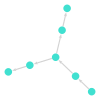

Tank Inventories
[0.27272727272727276, 0.375, 0.6000000000000001, 0.5454545454545454]
Flow Rate Alpha Weights
[1.0, 1.0, 1.0, 1.5, 1.0, 1.2]
Edge Weights
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [3]:
##############################
# ASSIGN WEIGHTS 
##############################
alpha_tk = assign_weights()

##############################
# CREATE MPC MODEL
##############################
mpc_model = create_mpc_model(alpha_tk)

    
println("Tank Inventories")
println(alpha_tk)
println("Flow Rate Alpha Weights")
println(alpha_f)
println("Edge Weights")
println(EI)


In [4]:
##############################
# RUN MPC
##############################
using JuMP
Hprofile = zeros(nt+1, NI)
Fprofile = zeros(nt, O)
Hprofile[1, :] = h0 
prev_f = f0 

for i = 1:nt

    # CHANGES TO CONSTRAINTS AND DISTURBANCE
    fmax = fmax_vec[:, i]
    Bd = Bd_vec[:, i]

    # CHANGES TO INITIAL CONDITIONS
    # h0 - Initial Height 

    # FIX INITIAL CONDITIONS IN MODEL AND RUN 
    fix.(mpc_model[:h][:, 1], h0, force=true)
    fix.(mpc_model[:prev_f], prev_f, force=true)

    # FIX DISTURBANCES IN MODEL
    fix.(mpc_model[:fmax], fmax, force=true)
    fix.(mpc_model[:Bd], Bd, force=true)

    # SOLVE MODEL 
    optimize!(mpc_model)
    status = JuMP.termination_status(mpc_model)

    if status != MOI.LOCALLY_SOLVED && status != MOI.OPTIMAL
        println("Model did not converge to global or local optima")
    else
        println("Model solved successfully")
    end

    println(status)

    # REASSIGN INITIAL CONDITIONS 
    # SAVE RESULTS FROM 2ND TIME STEP (FIRST TIME STEP IS INITIAL CONDITION)
    h0 = [value(mpc_model[:h][ni, 2]) for ni in 1:NI] 
    prev_f = [value(mpc_model[:f][o, 1]) for o in 1:O]   # the move just implemented

    Hprofile[i+1, :] = h0 
    Fprofile[i, :] = prev_f 


end 



Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved successfully
OPTIMAL
Model solved s

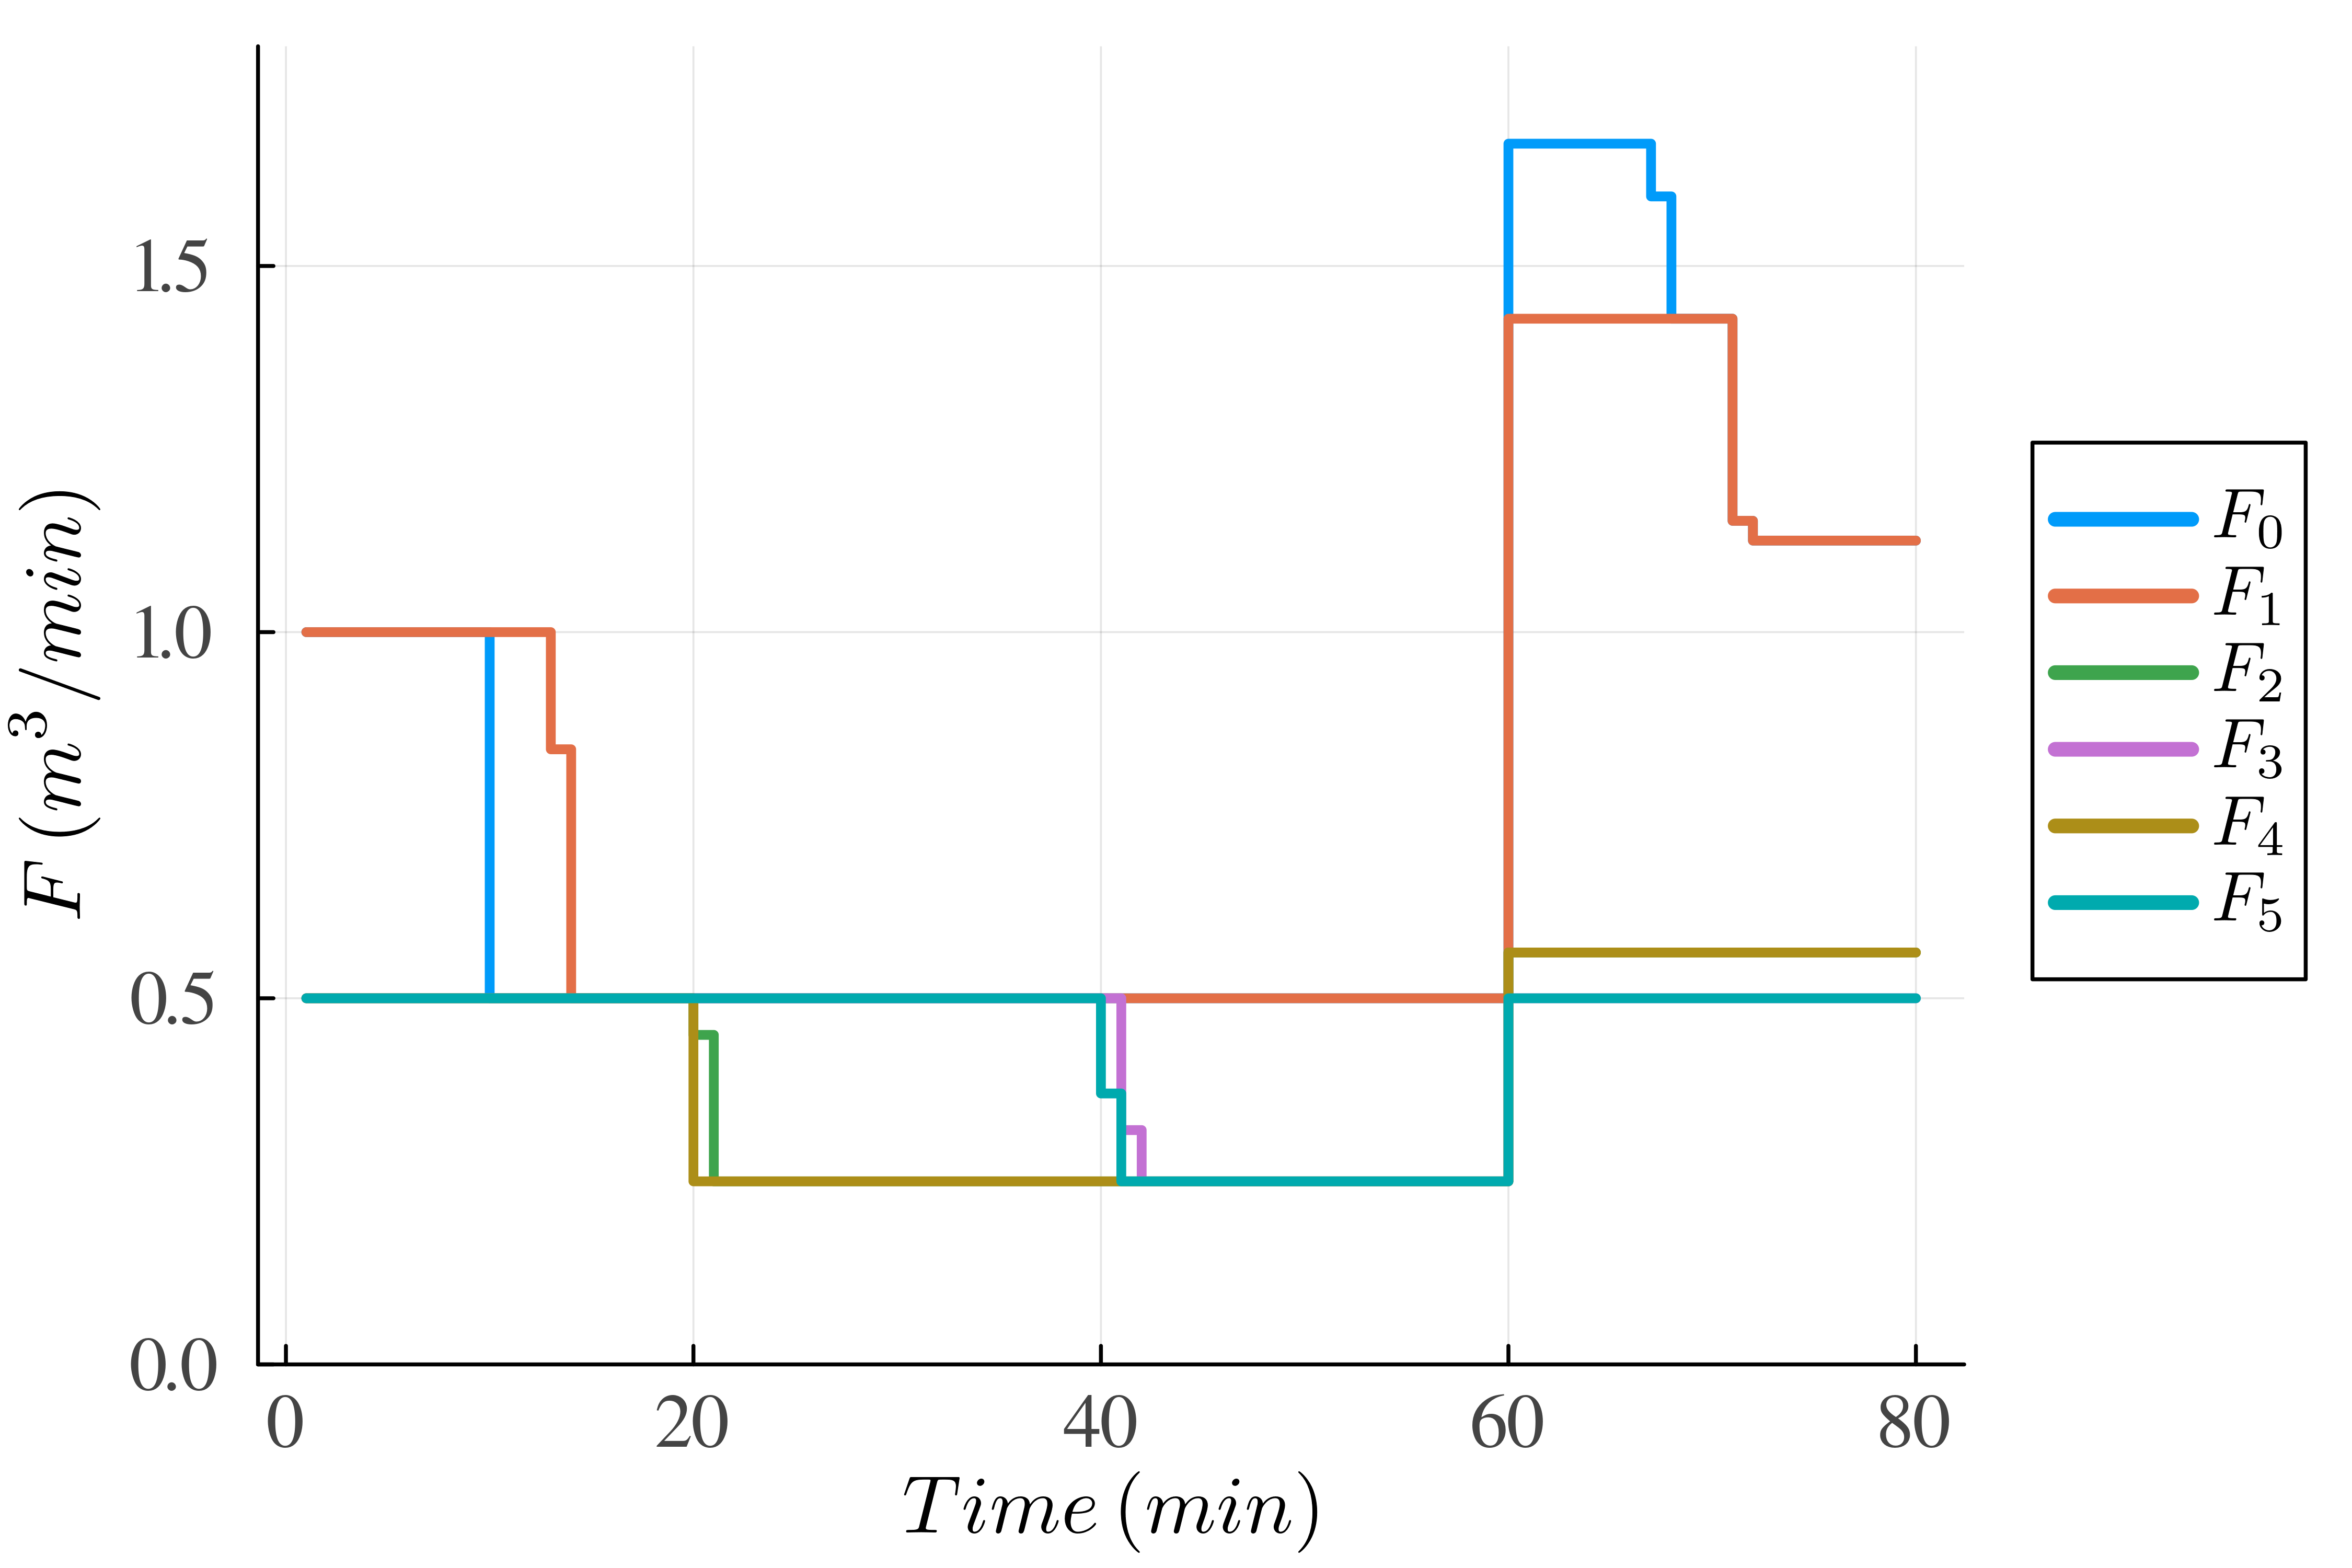

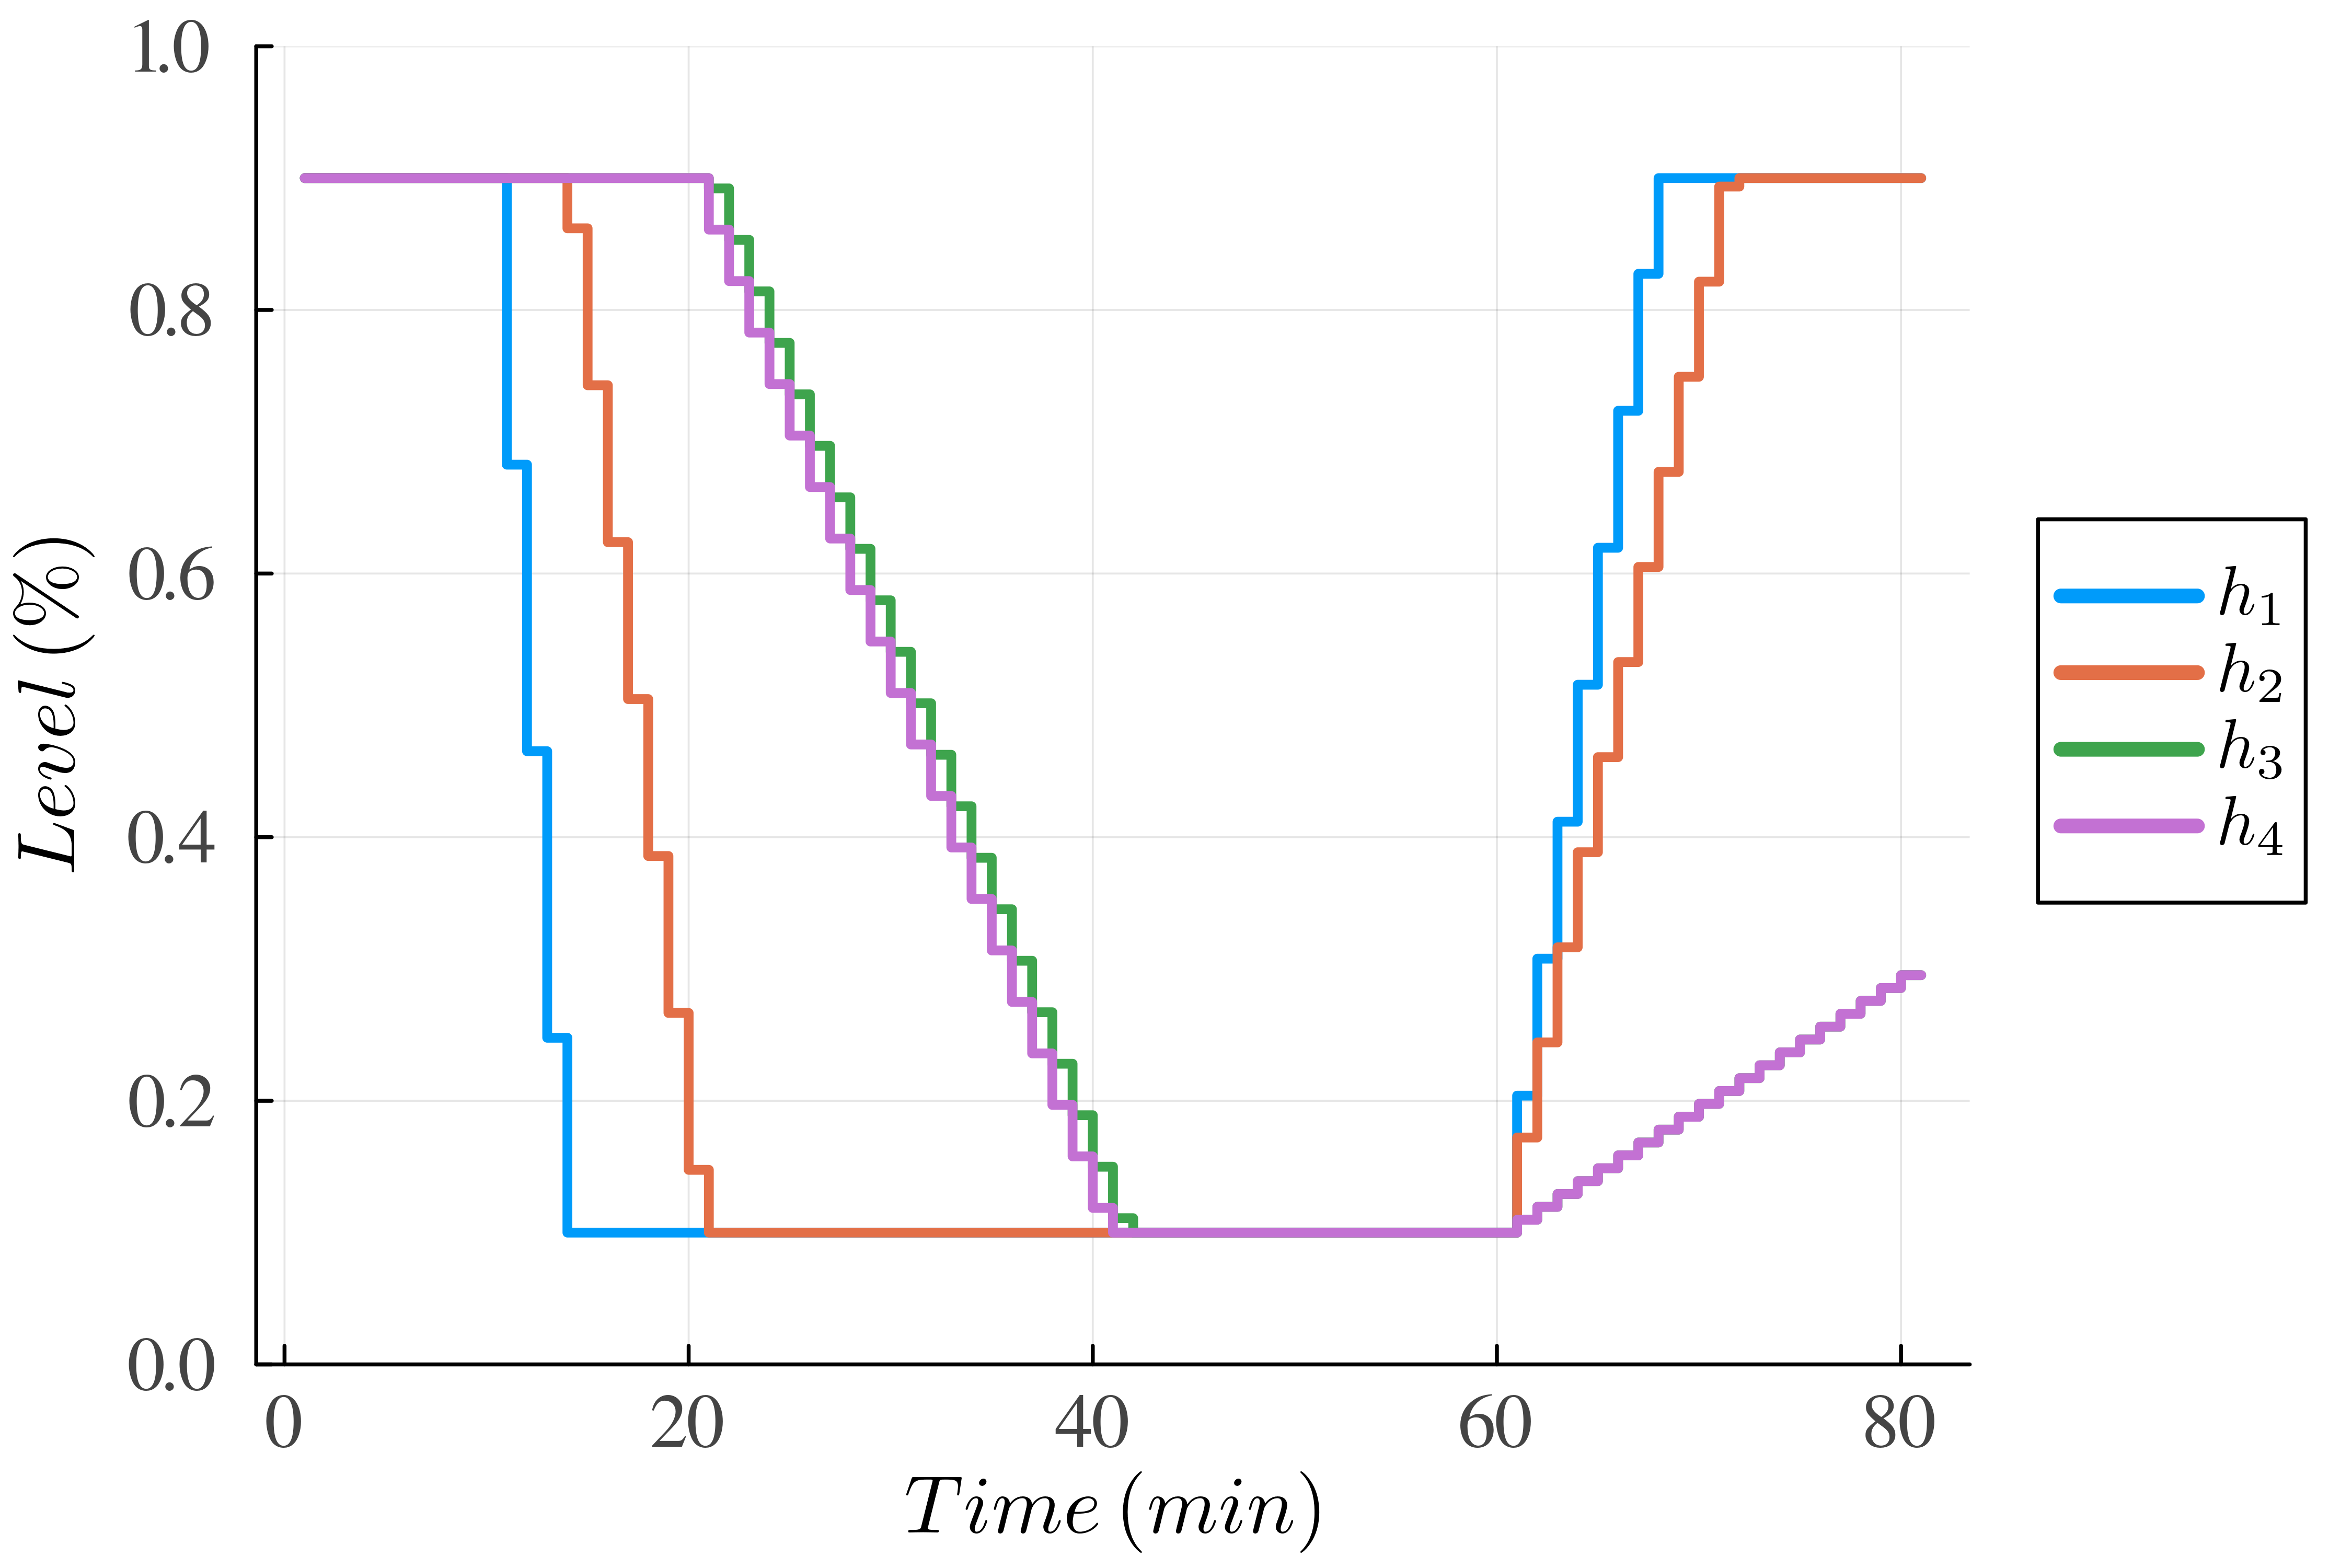

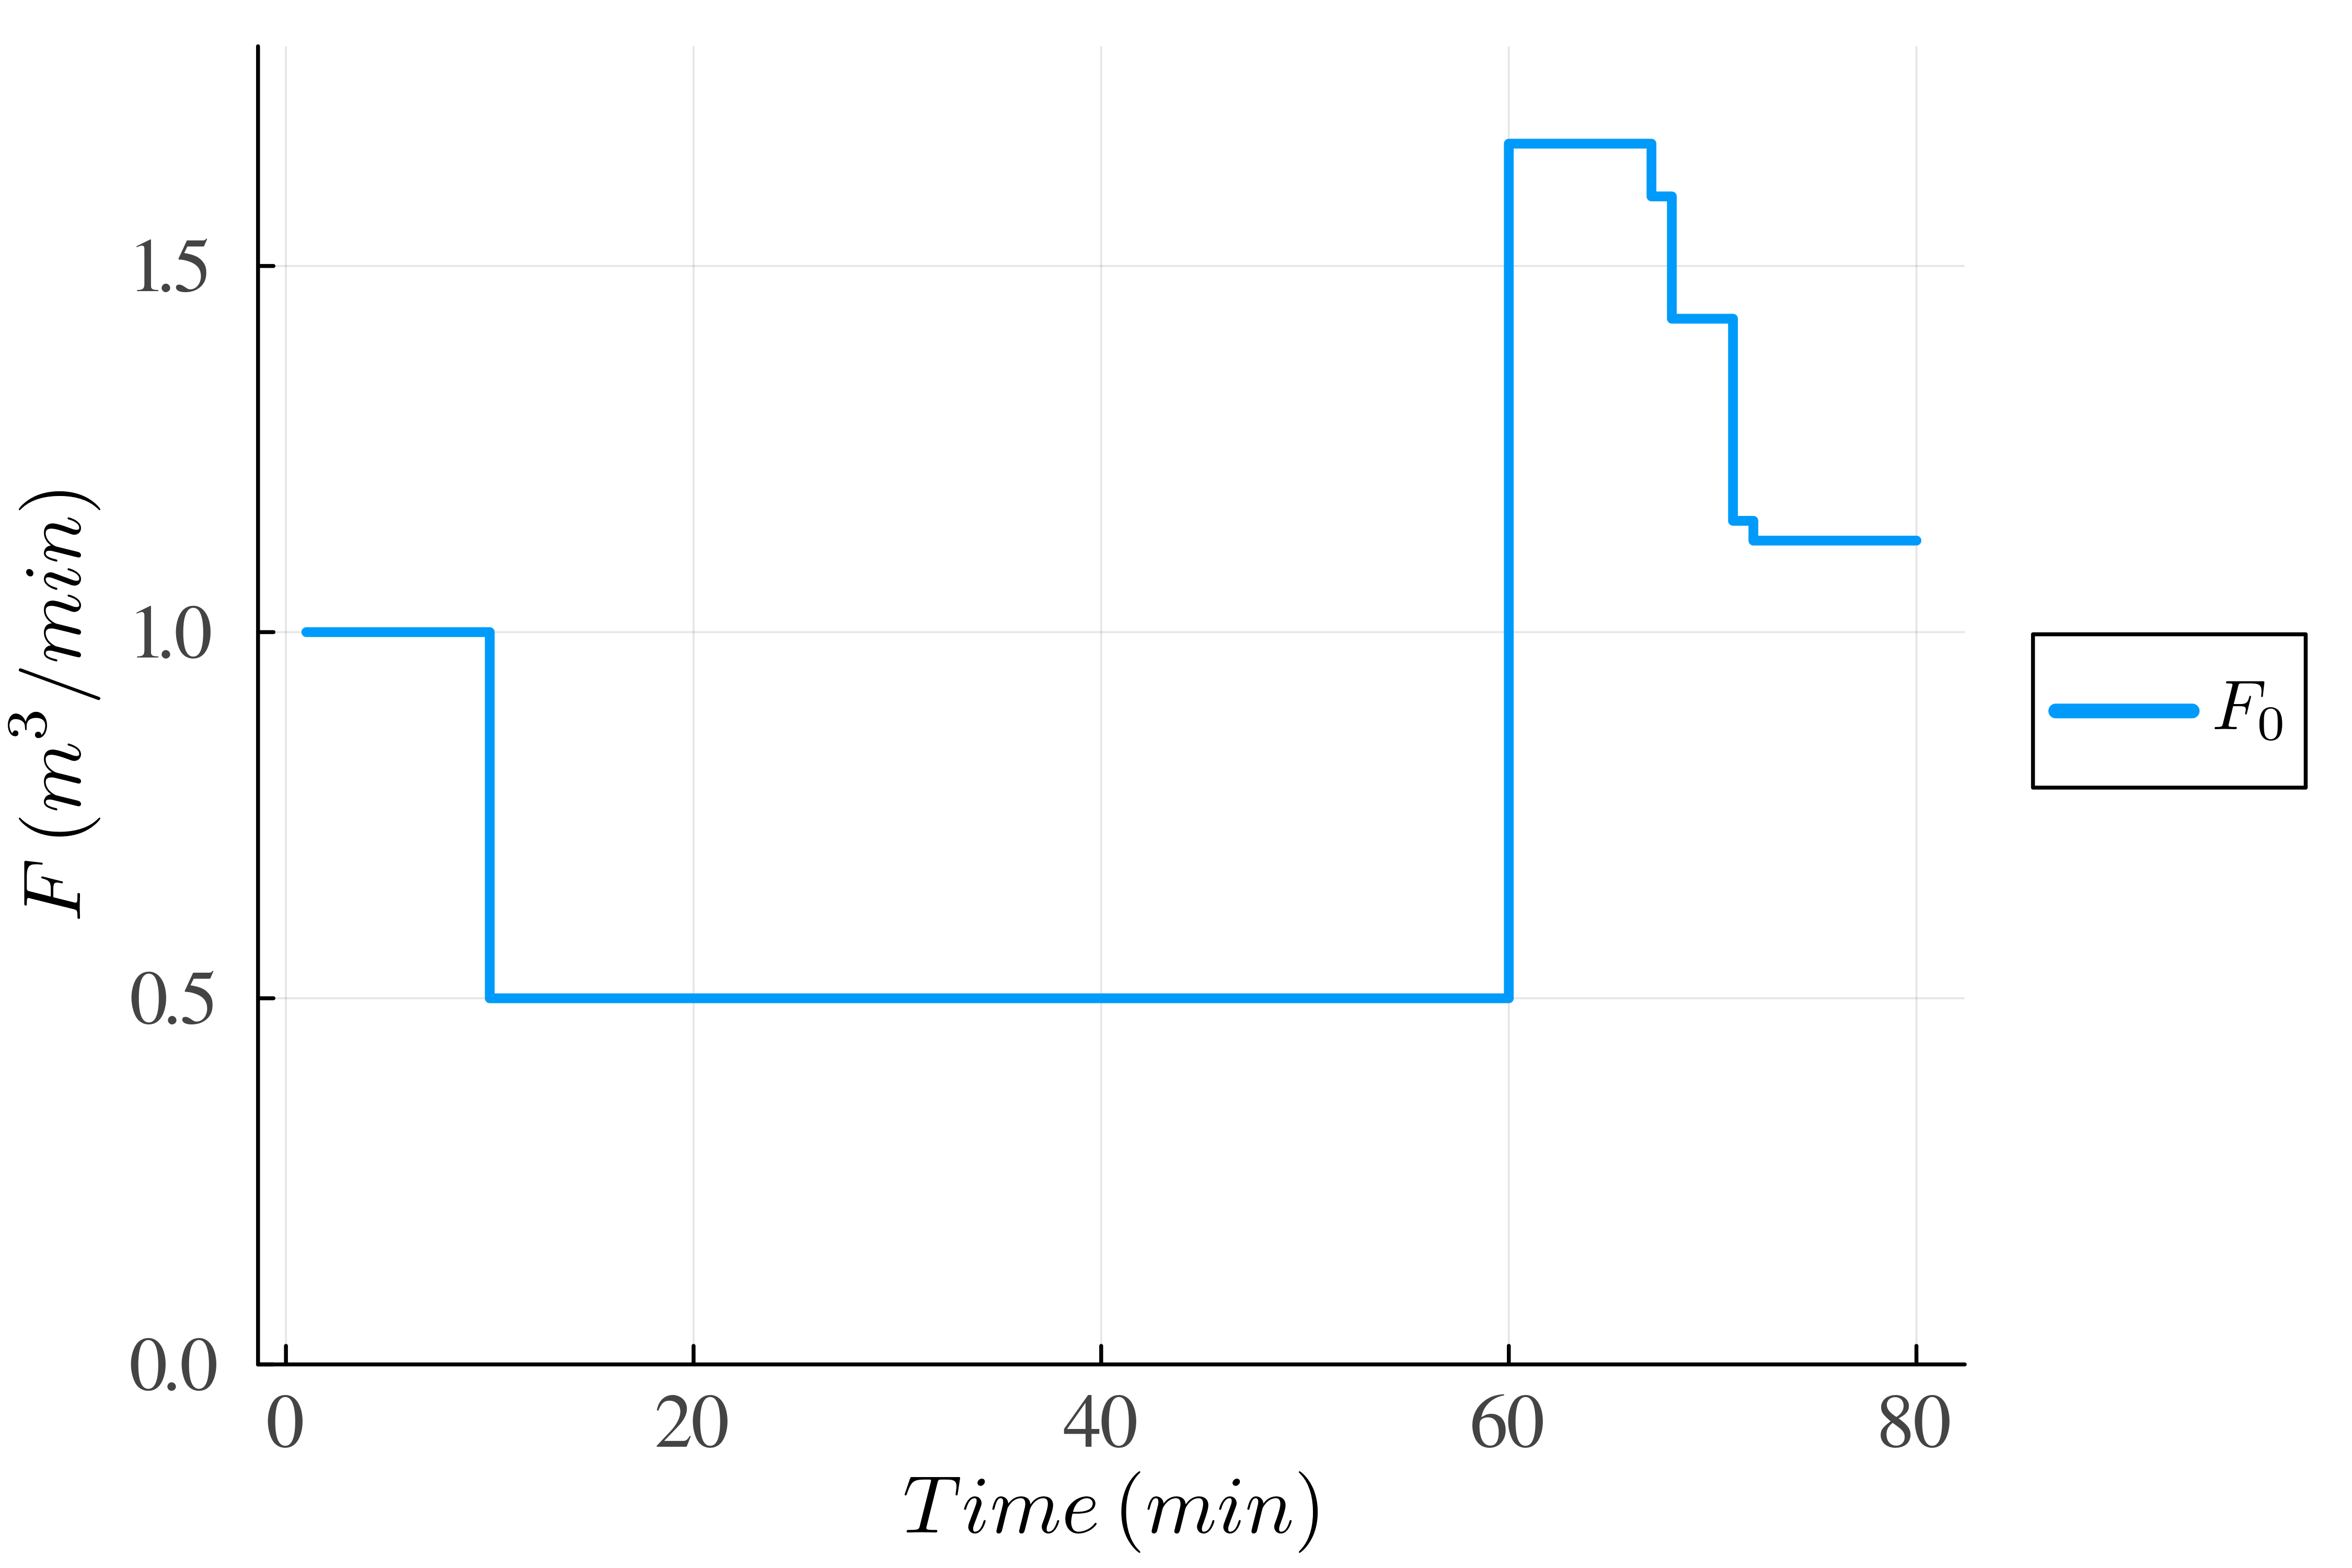

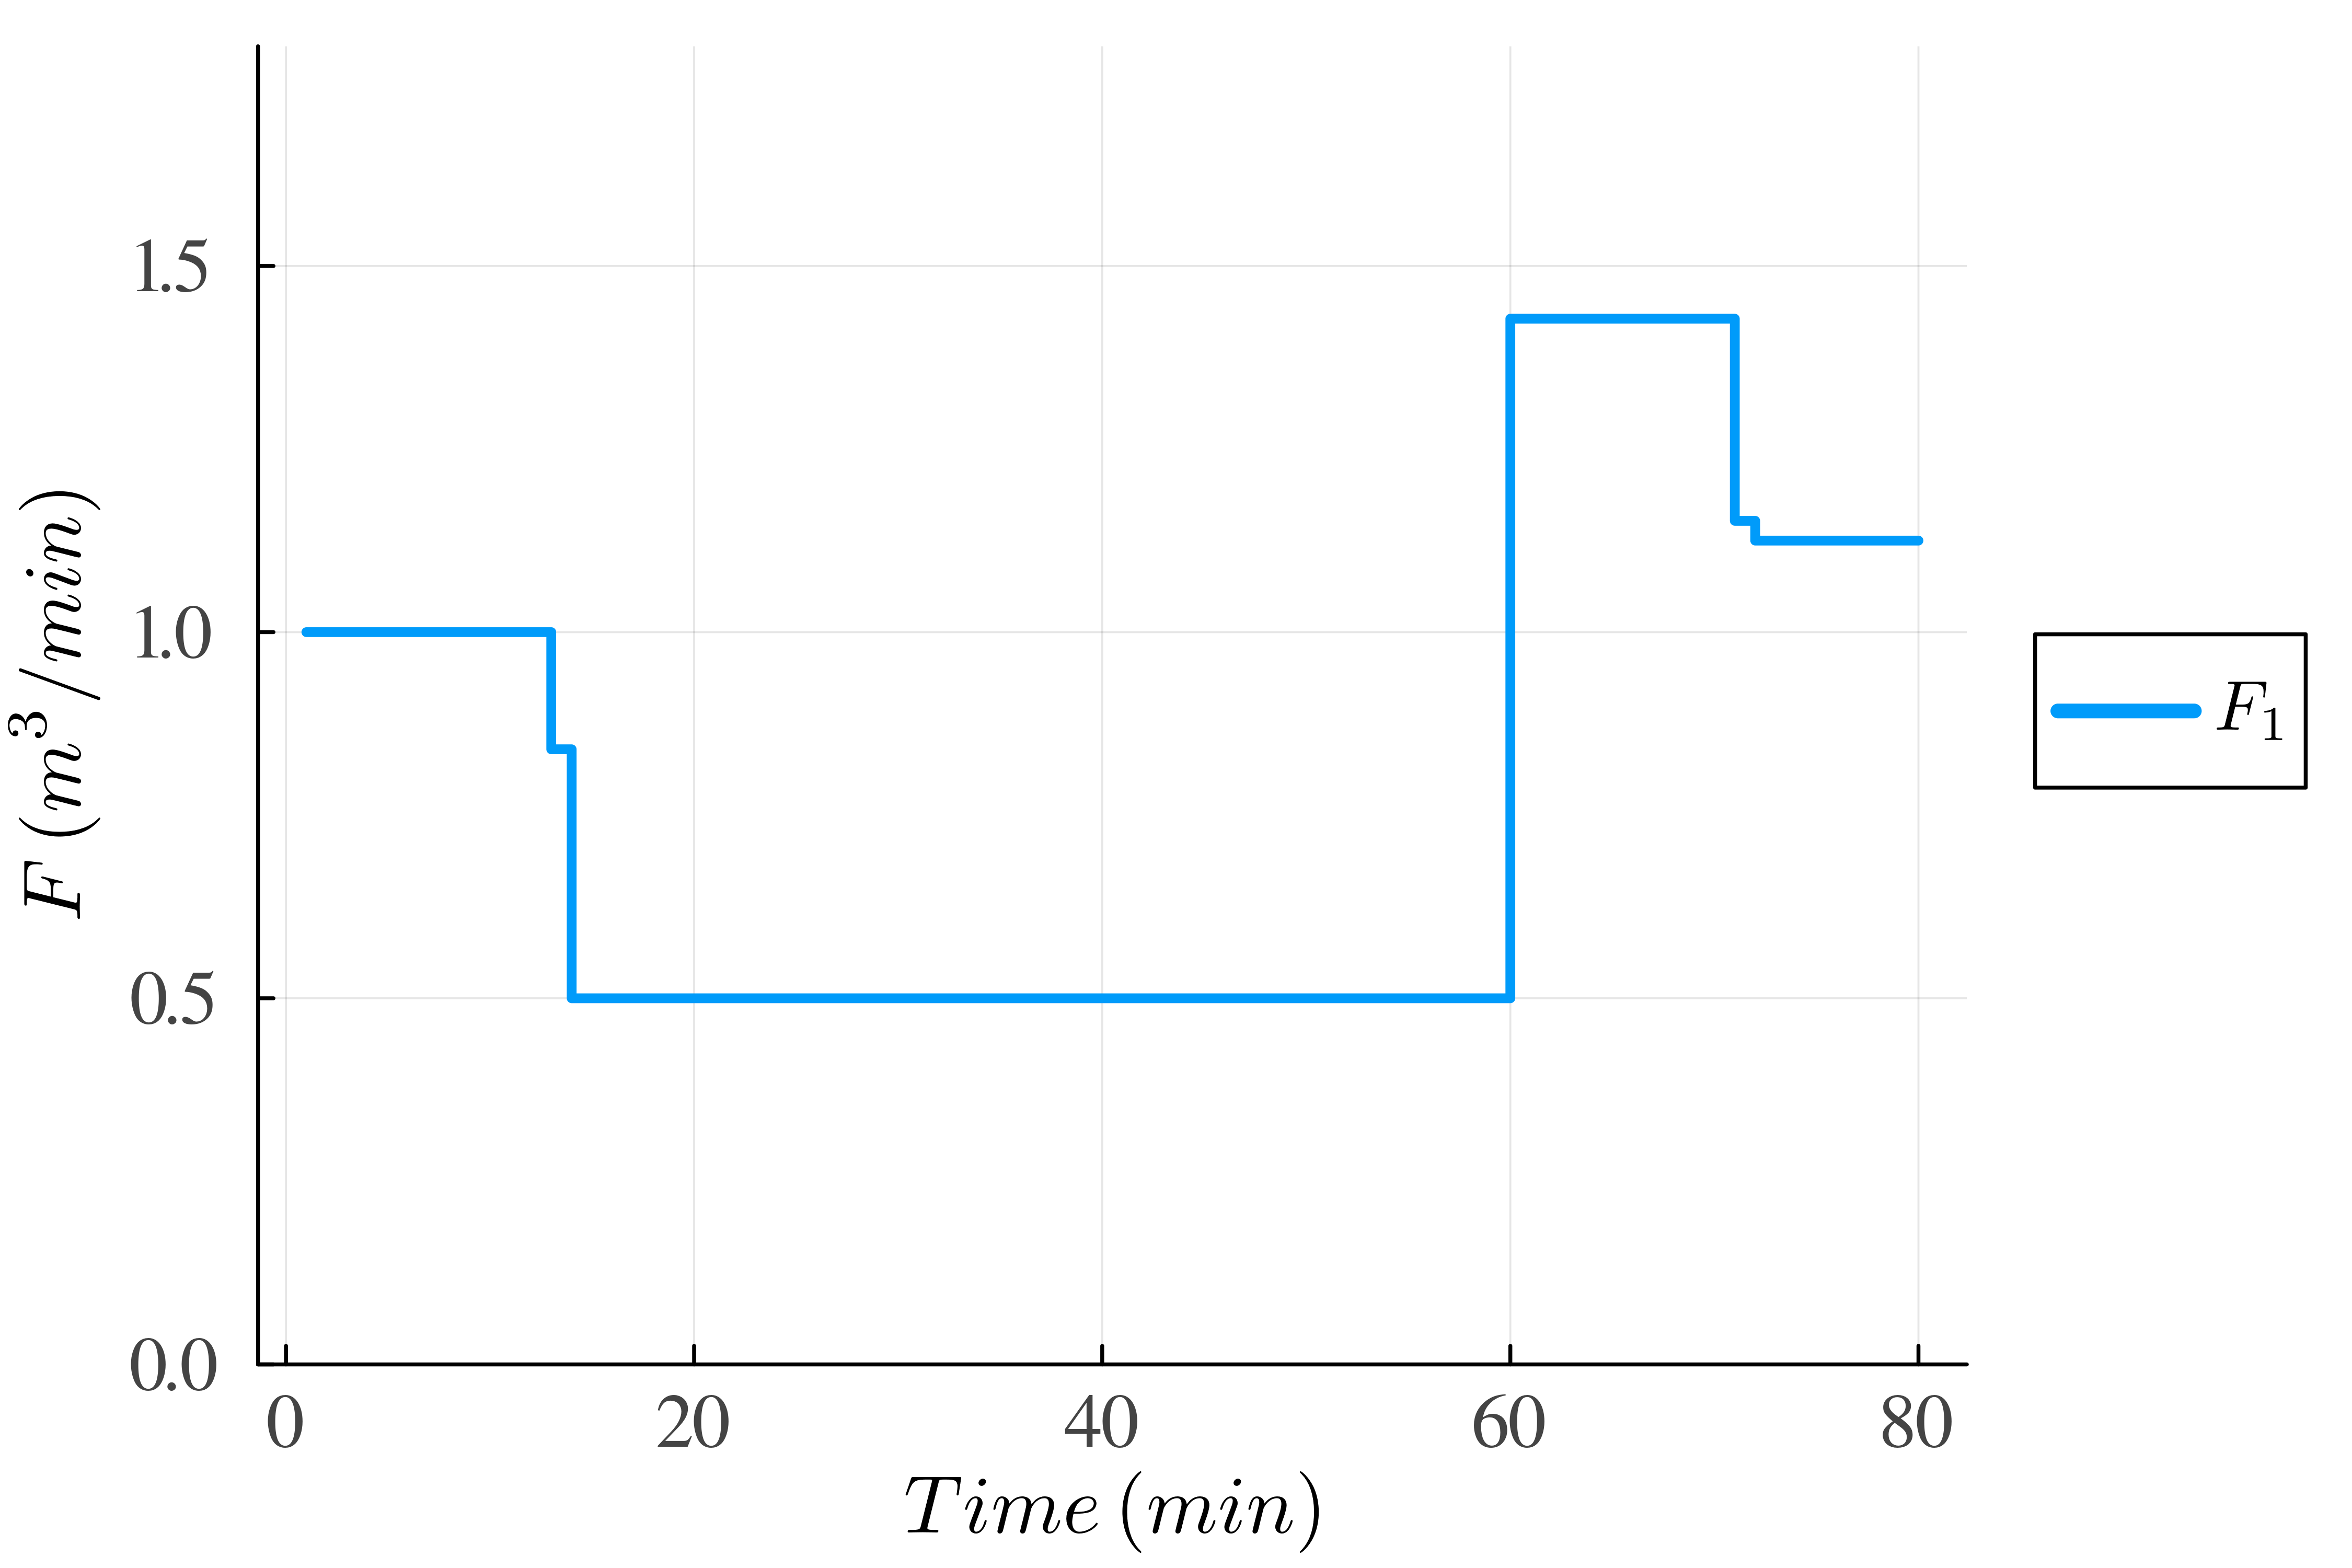

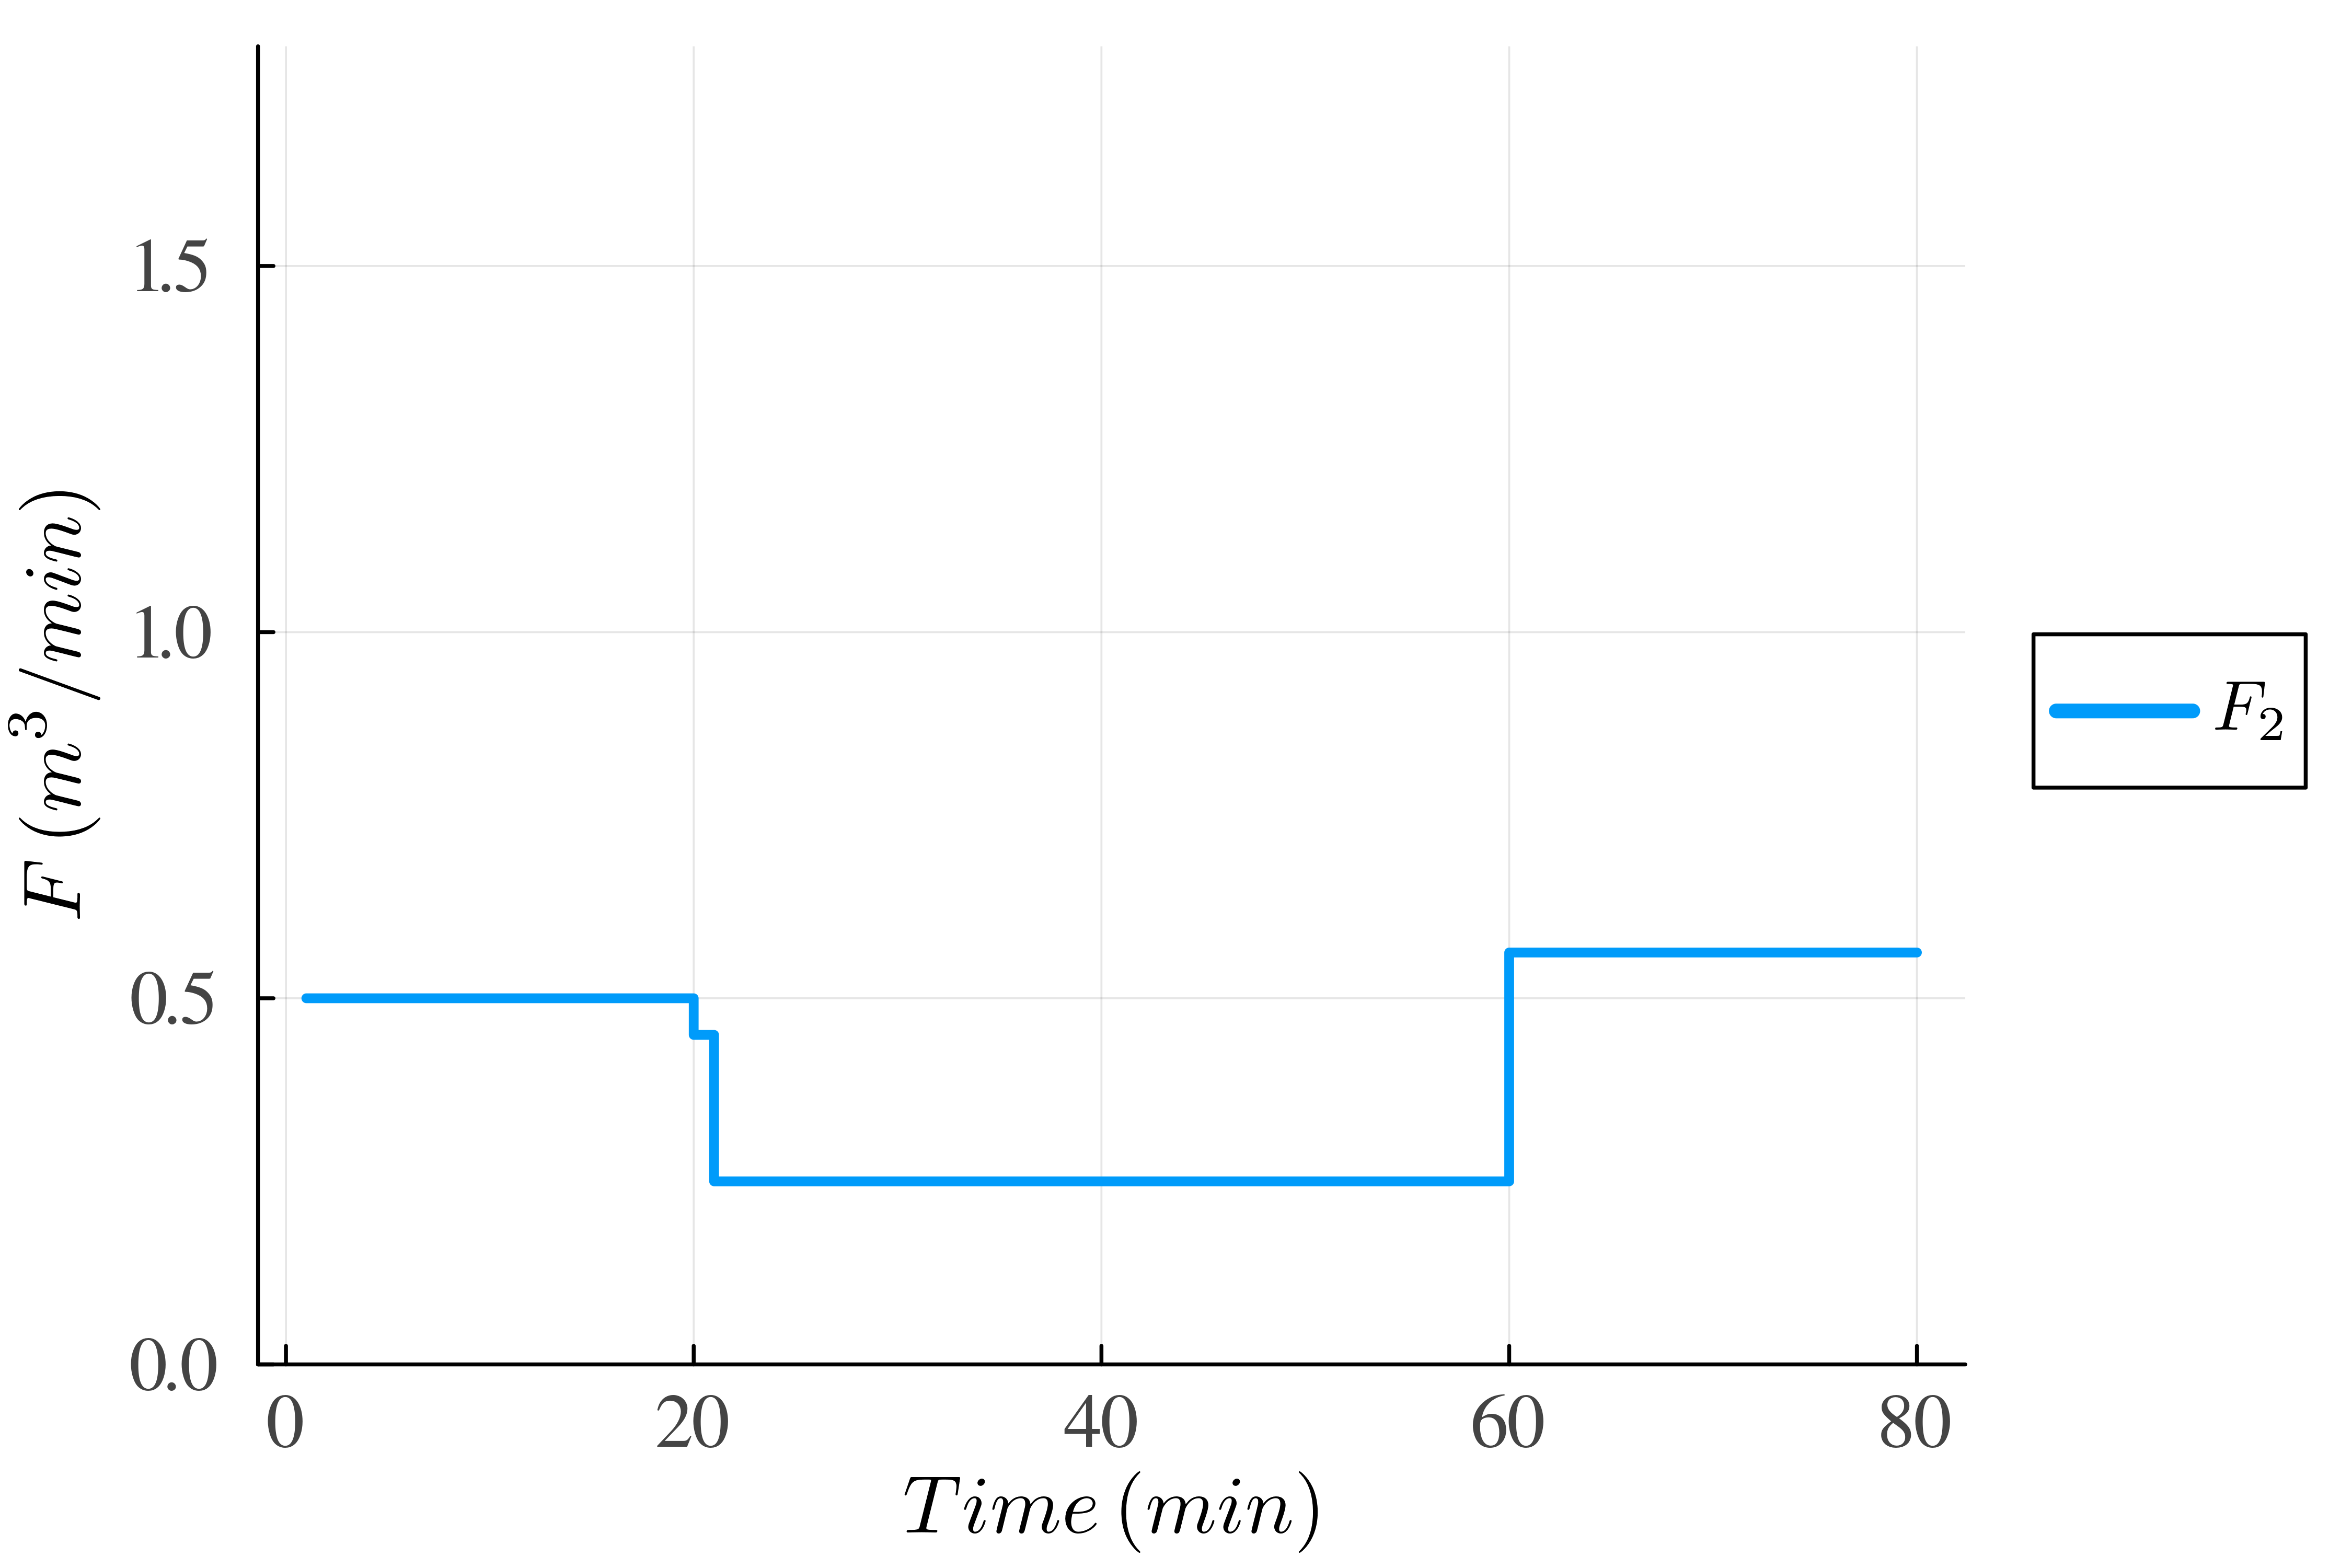

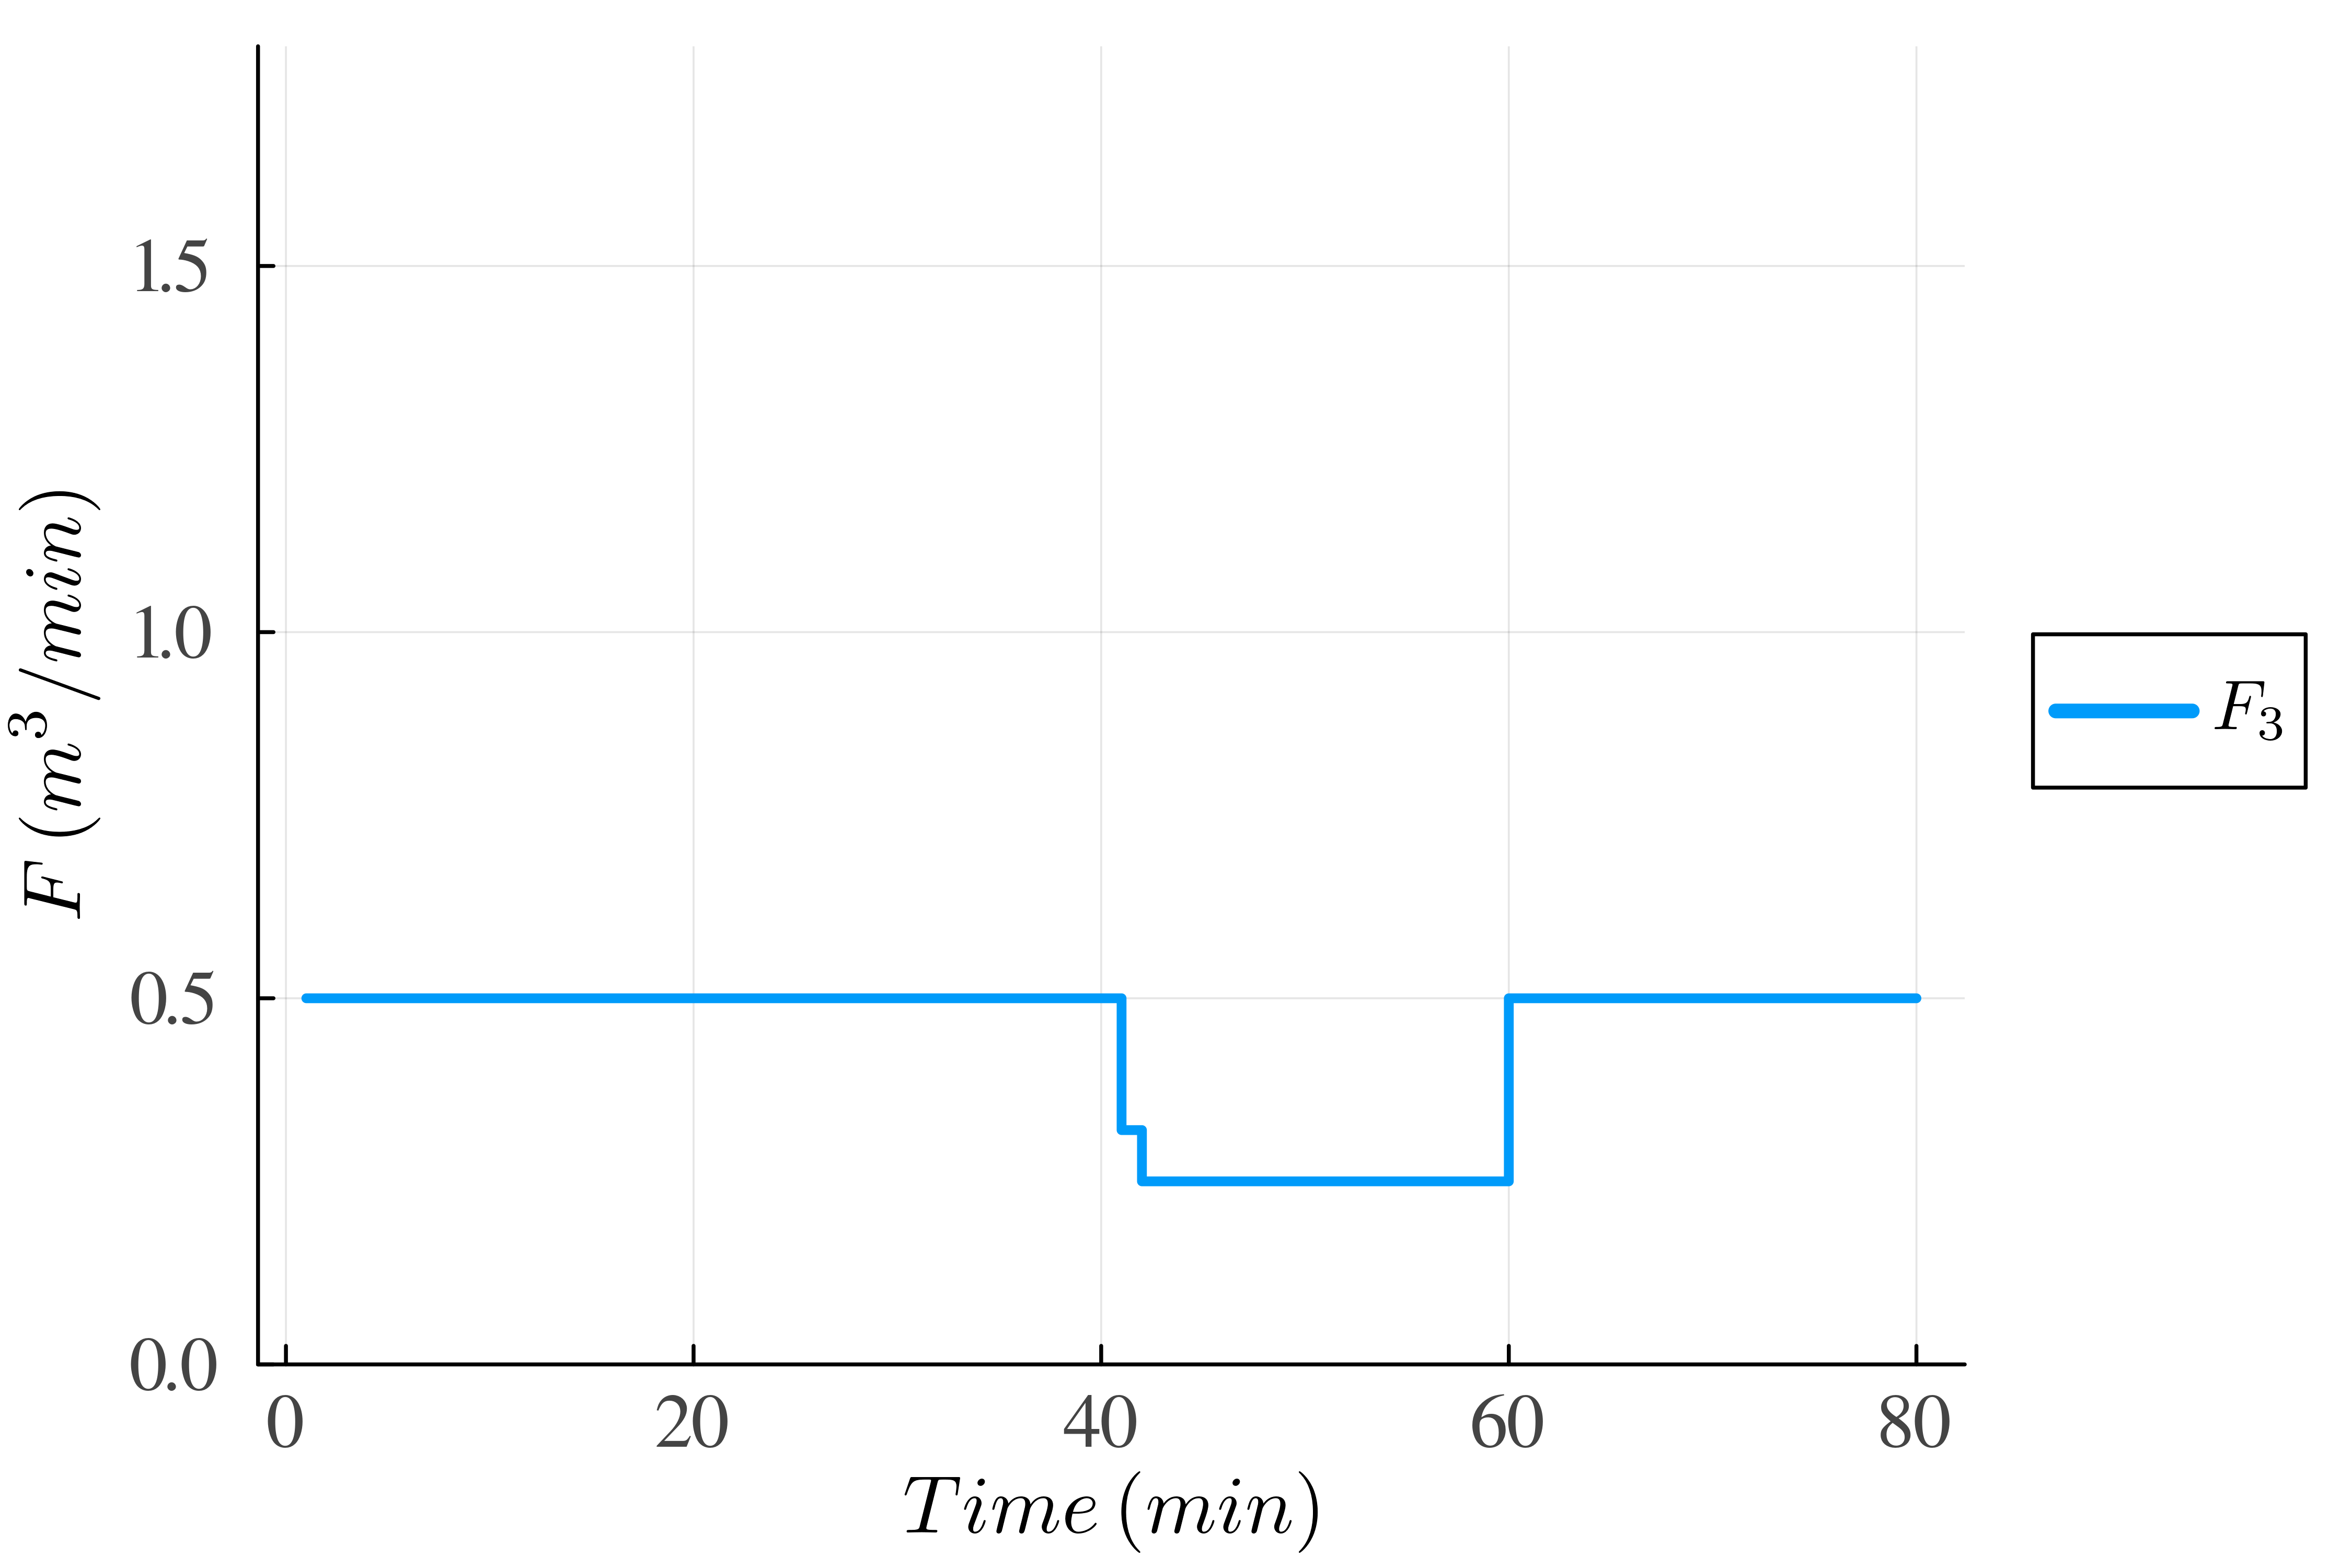

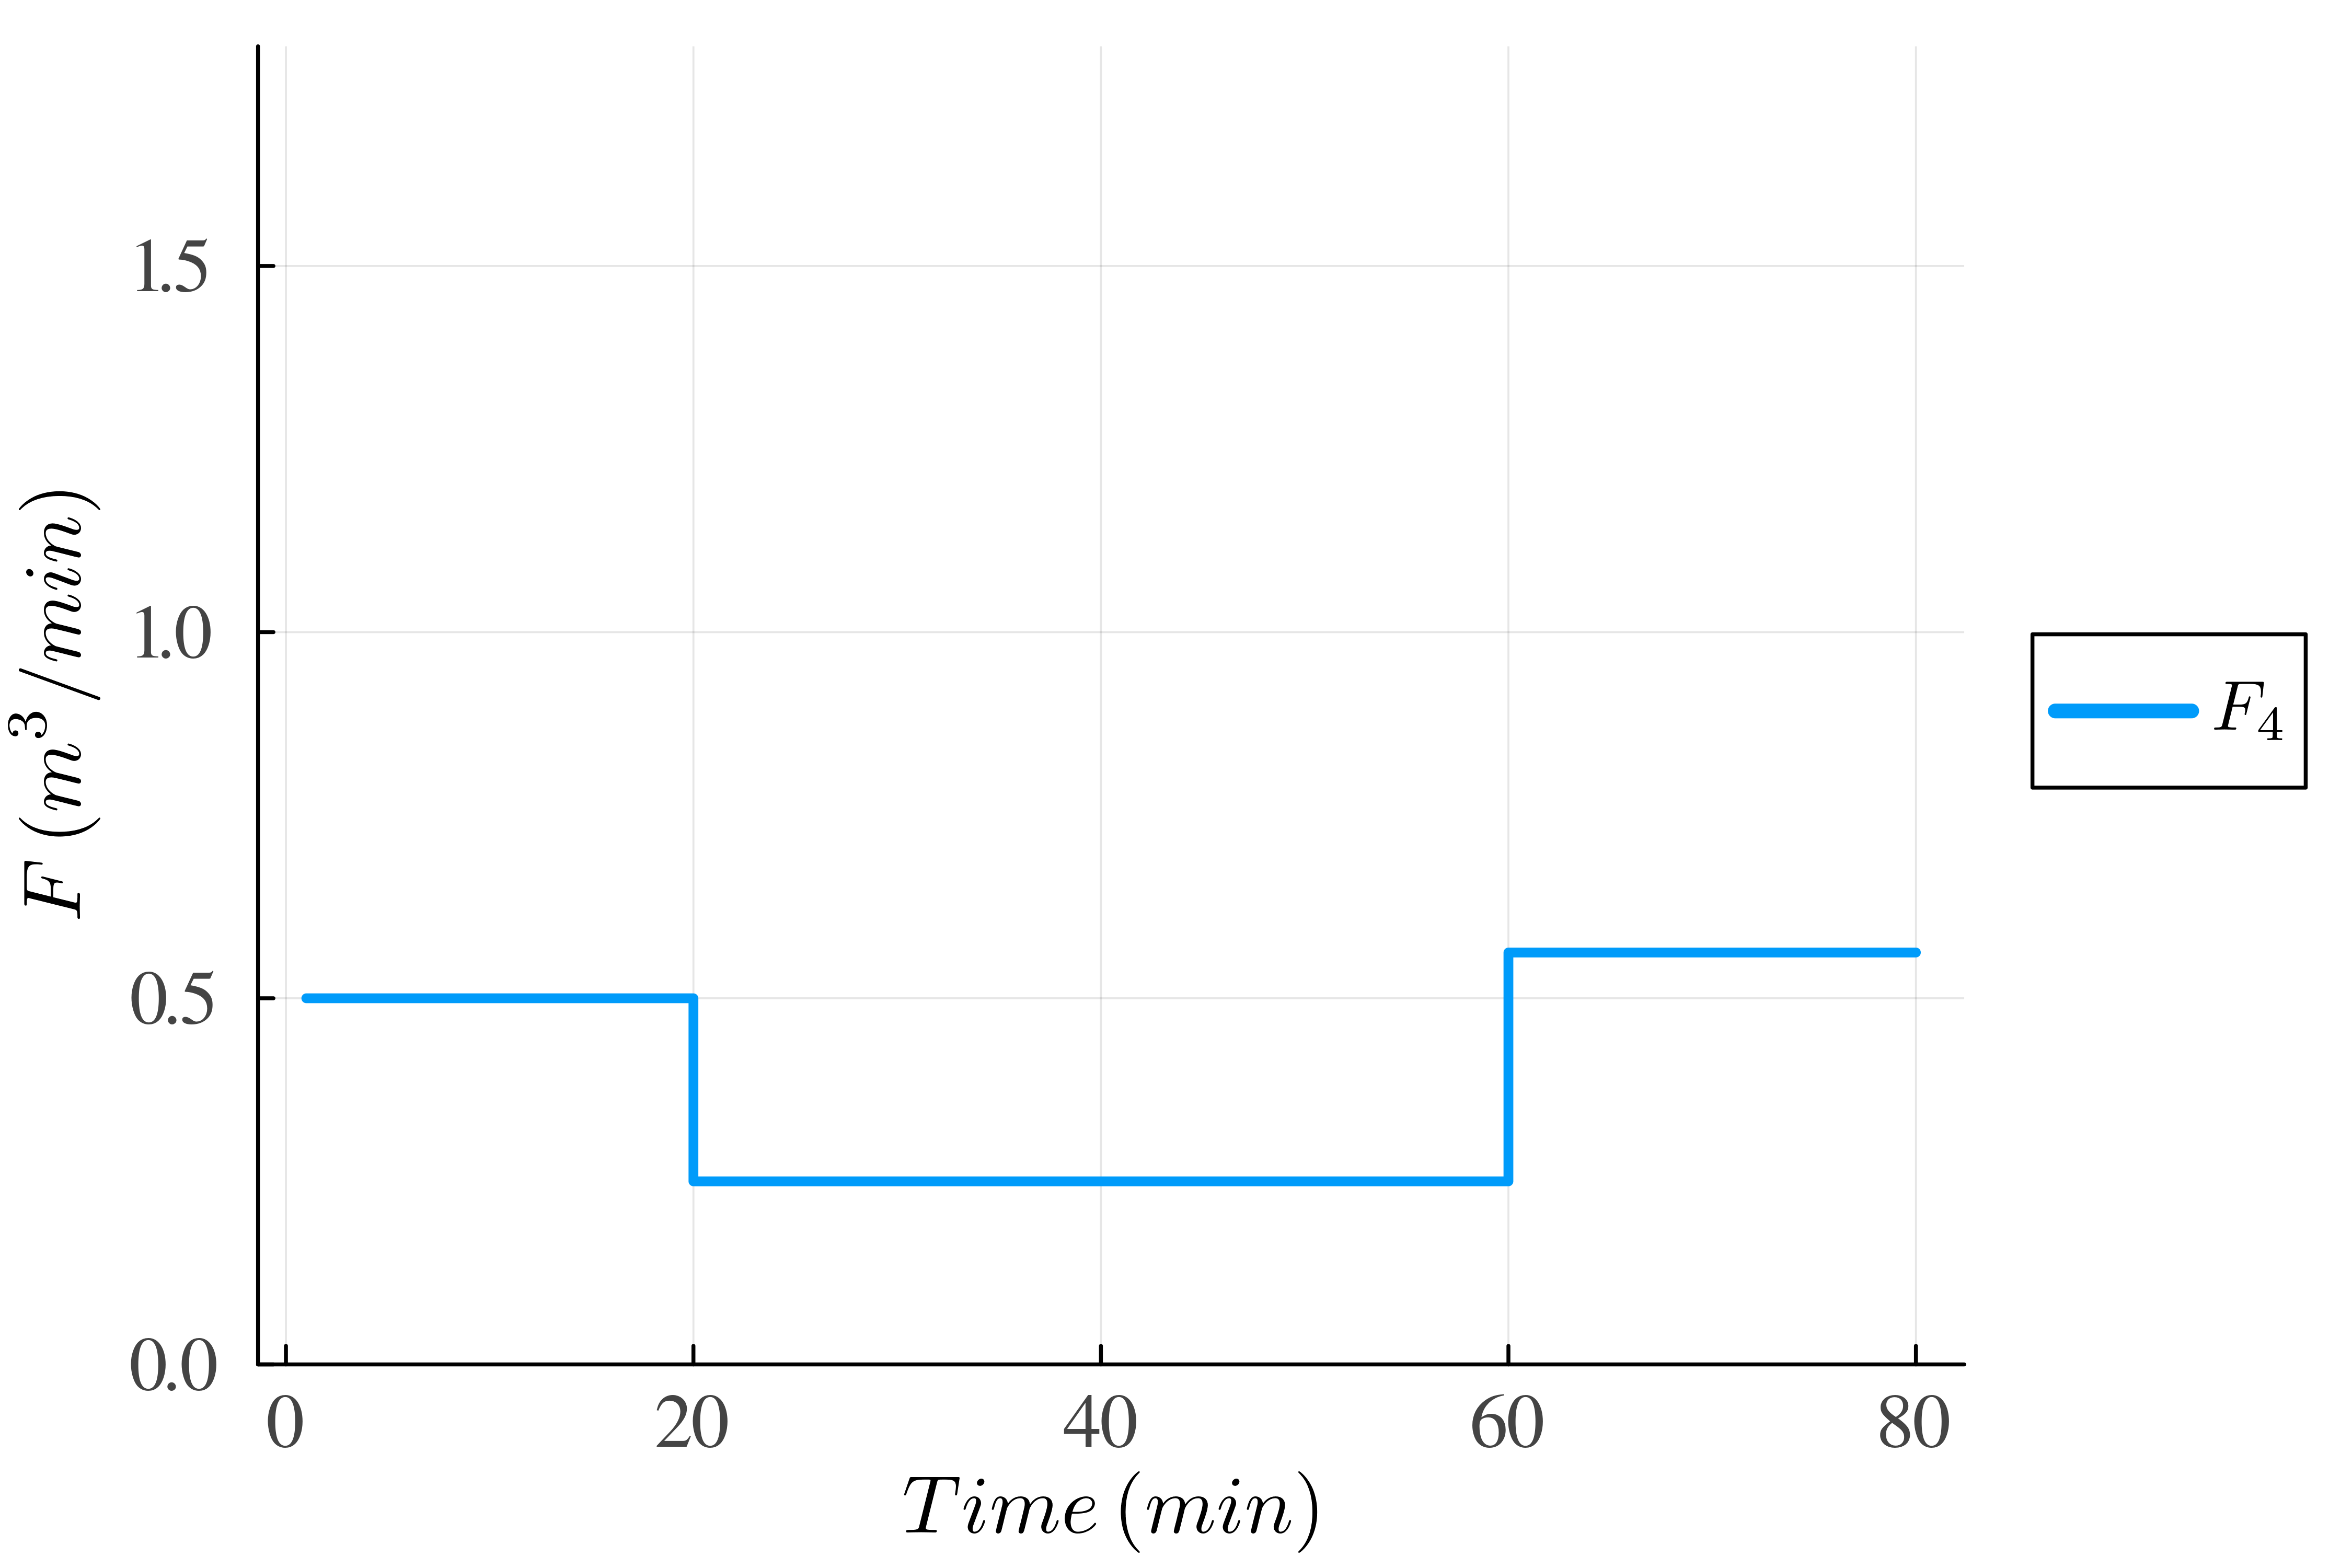

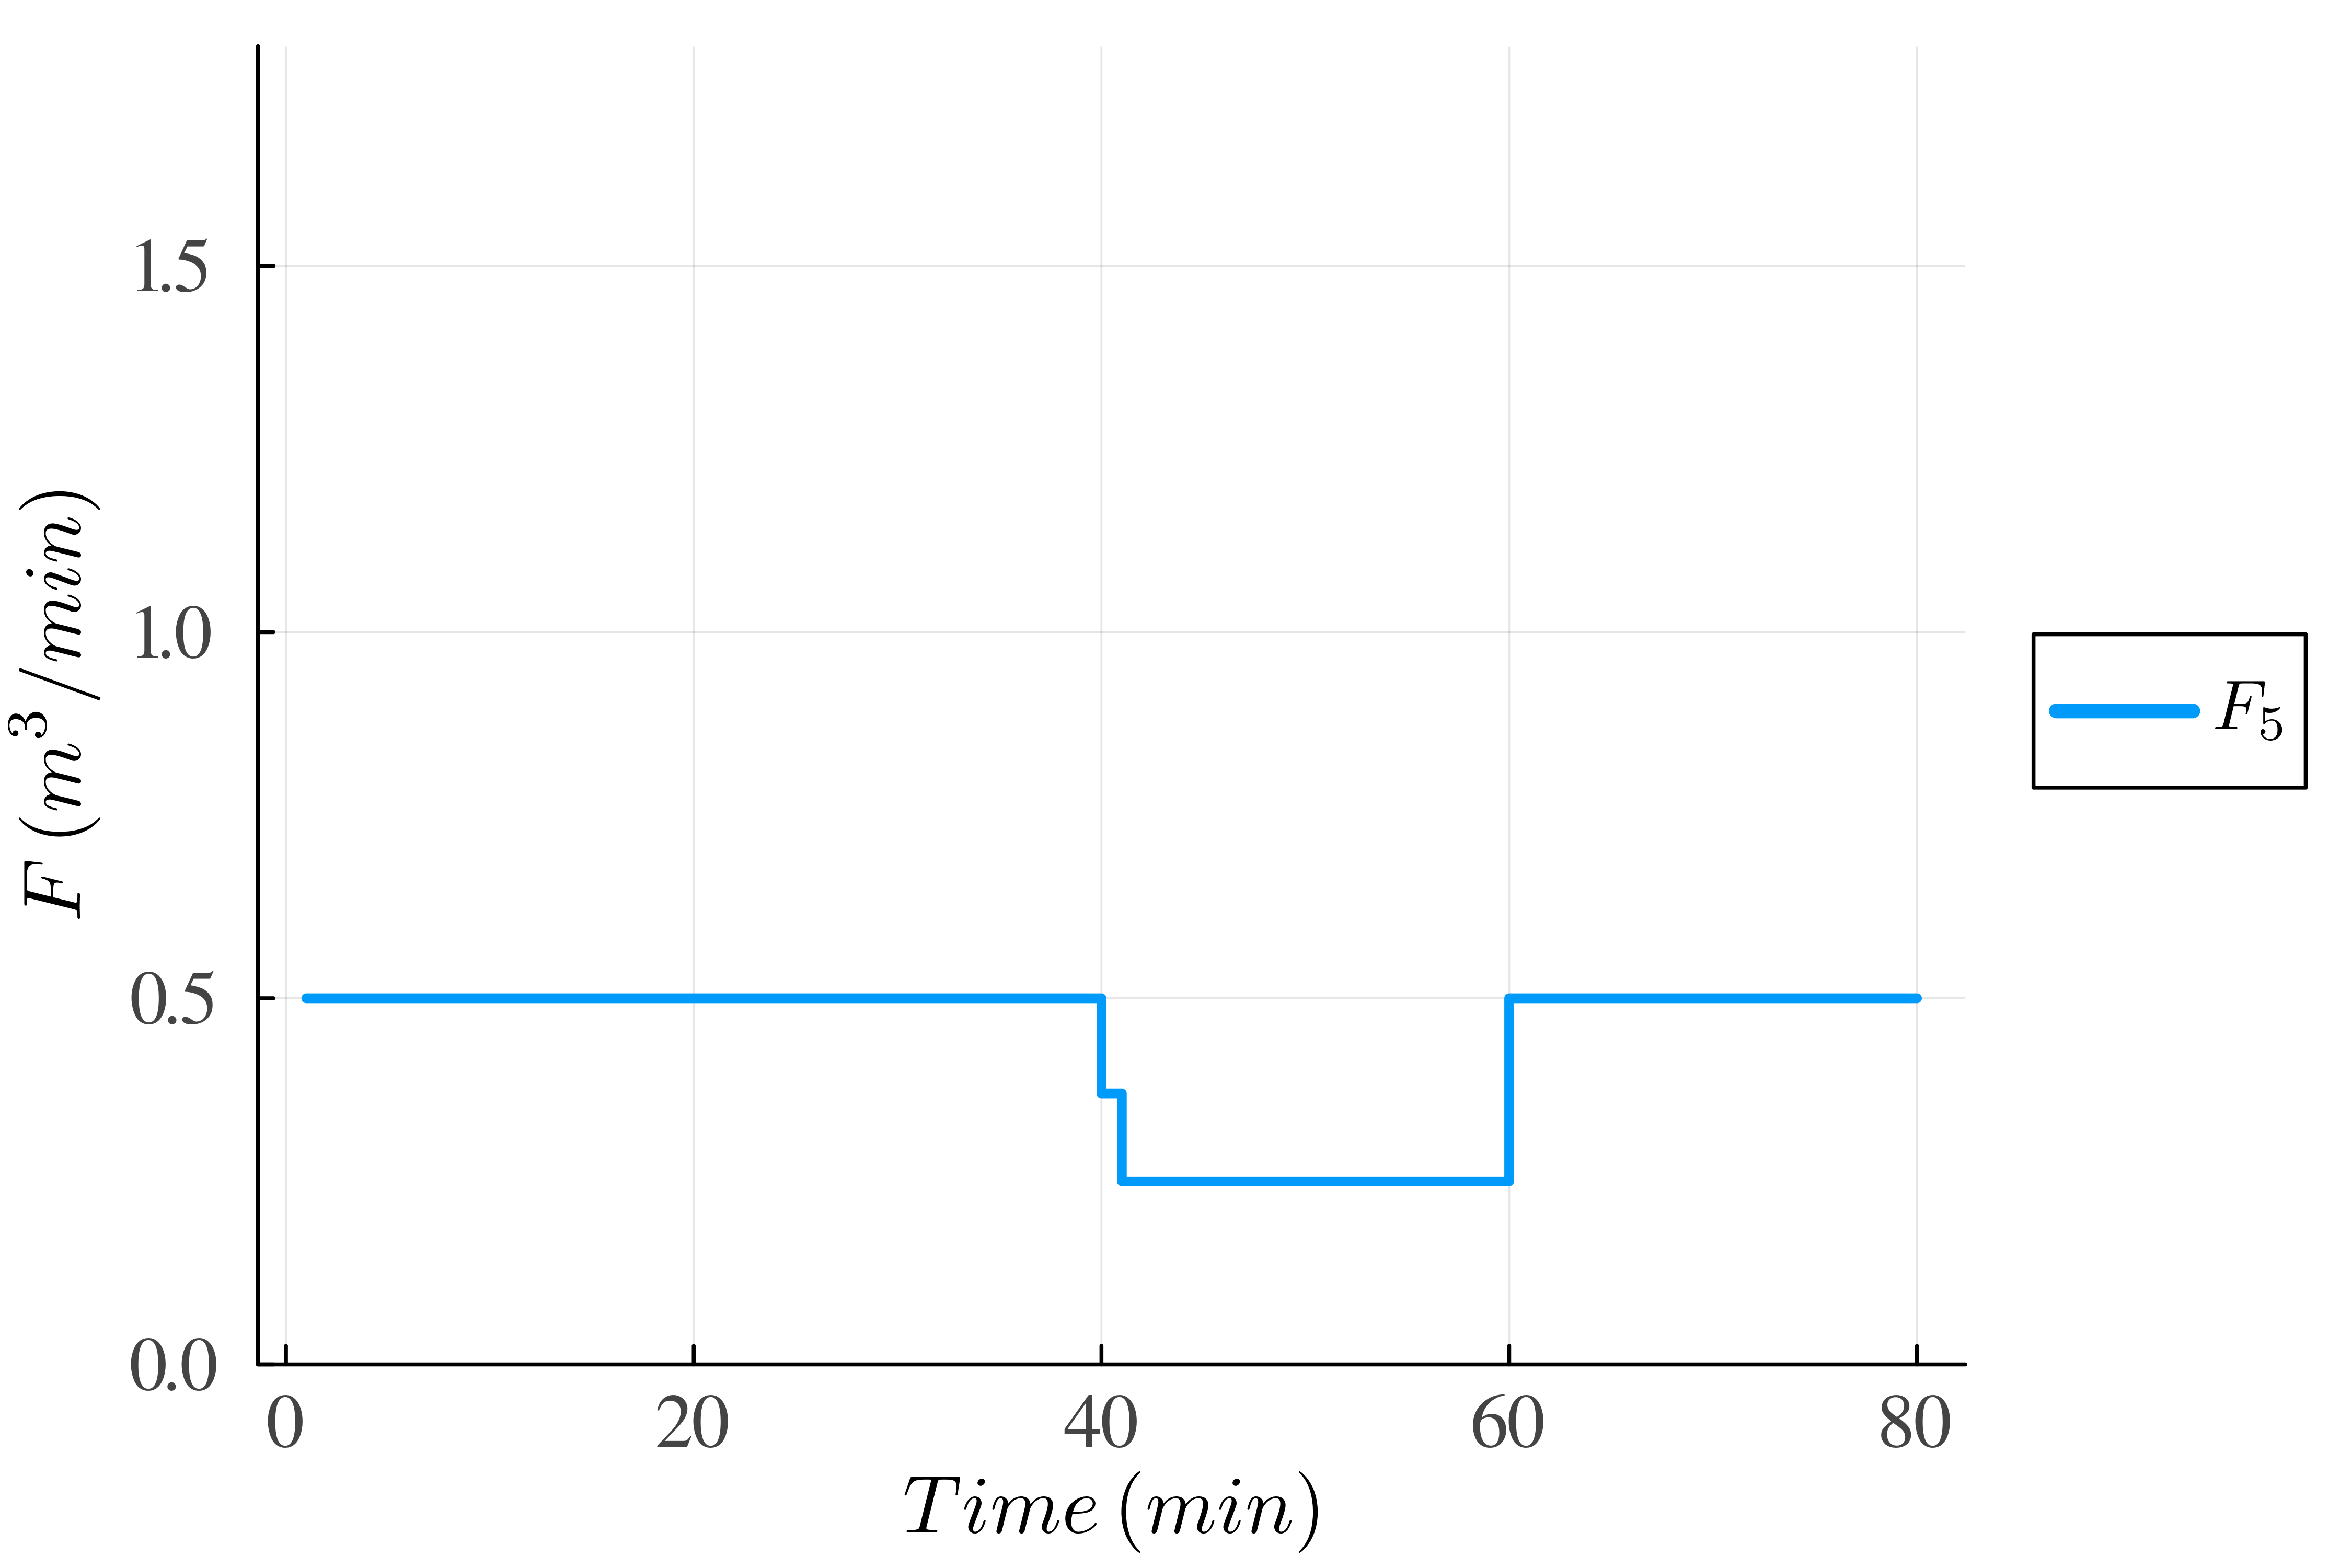

In [5]:
##############################
# PLOT AND SAVE RESULTS
##############################
fplt_ylim = (0.0, 1.8)
hplt_ylim = (0.0, 1.0)

plot_save_results(fplt_ylim, hplt_ylim, Hprofile, Fprofile, alpha_tk, original_dir)